In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression

hours = np.arange(0.5, 6, 0.5)
outcome = np.array([0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1])
data = pd.DataFrame.from_records(zip(hours, outcome), columns=['hours', 'outcome'])

In [2]:
hours

array([0.5, 1. , 1.5, 2. , 2.5, 3. , 3.5, 4. , 4.5, 5. , 5.5])

In [3]:
outcome

array([0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1])

In [4]:
data

,hours,outcome
0,0.5,0
1,1.0,0
2,1.5,0
3,2.0,0
4,2.5,0
5,3.0,0
6,3.5,1
7,4.0,0
8,4.5,1
9,5.0,0


## HOW MUCH DO I HAVE TO STUDY IN ORDER TO PASS THE EXAM??

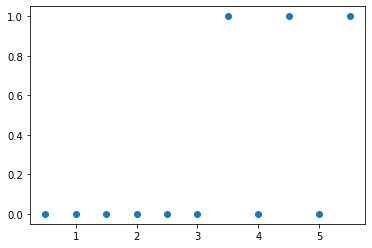

In [17]:
x = data['hours']
y = data['outcome']
plt.scatter(x,y)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   hours    11 non-null     float64
 1   outcome  11 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 304.0 bytes


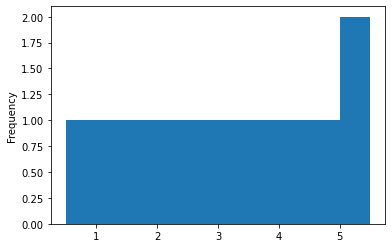

In [18]:
x.plot.hist()

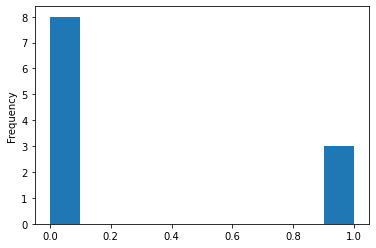

In [8]:
y.plot.hist()

In [10]:
logreg = LogisticRegression(solver='lbfgs', multi_class='ovr')

In [20]:
## It's (11,) --> must be (11,1)
x.shape

(11,)

In [21]:
logreg.fit(x,y)

ValueError: Expected 2D array, got 1D array instead:
array=[0.5 1.  1.5 2.  2.5 3.  3.5 4.  4.5 5.  5.5].
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.

In [22]:
x = x.values.reshape(-1,1)

In [23]:
x.shape

(11, 1)

In [24]:
logreg.fit(x,y)

LogisticRegression(multi_class='ovr')

In [25]:
logreg.get_params()

{'C': 1.0,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': None,
 'max_iter': 100,
 'multi_class': 'ovr',
 'n_jobs': None,
 'penalty': 'l2',
 'random_state': None,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

In [26]:
logreg.predict_proba([[3]])

array([[0.79375149, 0.20624851]])

In [27]:
logreg.predict_proba([[20]])

array([[2.35290847e-06, 9.99997647e-01]])

In [28]:
logreg.predict_proba([[5]])

array([[0.41689037, 0.58310963]])

In [29]:
hours = np.arange(0, 30, 0.5)

In [30]:
hours

array([ 0. ,  0.5,  1. ,  1.5,  2. ,  2.5,  3. ,  3.5,  4. ,  4.5,  5. ,
        5.5,  6. ,  6.5,  7. ,  7.5,  8. ,  8.5,  9. ,  9.5, 10. , 10.5,
       11. , 11.5, 12. , 12.5, 13. , 13.5, 14. , 14.5, 15. , 15.5, 16. ,
       16.5, 17. , 17.5, 18. , 18.5, 19. , 19.5, 20. , 20.5, 21. , 21.5,
       22. , 22.5, 23. , 23.5, 24. , 24.5, 25. , 25.5, 26. , 26.5, 27. ,
       27.5, 28. , 28.5, 29. , 29.5])

In [31]:
probabilities = []
for h in hours:
    p_fail, p_pass = logreg.predict_proba([[h]])[0]
    probabilities.append(p_pass)

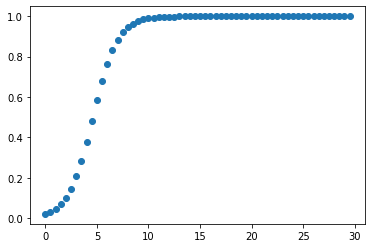

In [32]:
plt.scatter(hours, probabilities)

## TO HAVE 80% PROBABILITY OF PASSING I HAVE TO STUDY AT LEAST 7 HOURS